# Remote Data Job Landscape

**Goal:** Identify which countries and roles offer the most remote data job opportunities.

**Input:** `data_jobs_clean.parquet` (cleaned dataset from `1_data_cleaning.ipynb`)

**What this notebook covers:**
- Overview of remote vs on-site postings
- Countries where remote data roles are most searched/posted
- Job titles most associated with remote work
- Key visualizations and takeaways

---

In [2]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading cleaned dataset
df = pd.read_parquet('../data/clean/data_jobs_clean.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      785741 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

## Remote Work Overview

### Verifying the right column for country-level remote analysis
Since remote postings are flagged with `job_location == 'Anywhere'`, this column can't be used to determine *which* country a remote opportunity is tied to. Checking `job_country` and `search_location` to identify the right field for this analysis.

In [3]:
df[df['job_work_from_home'] == True][['job_country', 'search_location']].head(10)

,job_country,search_location
5,United States,Georgia
7,Romania,Romania
9,United States,"New York, United States"
24,Serbia,Serbia
51,United States,"Illinois, United States"
56,Ireland,Ireland
73,United States,"Illinois, United States"
76,Philippines,Philippines
85,Canada,Canada
88,Mexico,Mexico


**Finding**: `job_country` provides a consistent country-level value across all rows, while `search_location` sometimes includes sub-regions (e.g., "Illinois, United States"). `job_country` will be used for all country-level remote analysis going forward.

### Remote vs On-Site Postings — Overall Split

In [4]:
remote_counts = df['job_work_from_home'].value_counts(normalize=True) * 100
remote_counts.index = ['On-site', 'Remote']
remote_counts

On-site    91.148228
Remote      8.851772
Name: proportion, dtype: float64

### Top Countries Offering Remote Data Roles

In [5]:
top_remote_countries = (
    df[df['job_work_from_home'] == True]['job_country']
    .value_counts()
    .head(10)
)
top_remote_countries

job_country
United States     23021
India              5712
Sudan              3930
United Kingdom     3764
Canada             2812
Spain              2645
Poland             1857
France             1694
Mexico             1619
Brazil             1542
Name: count, dtype: int64

### Remote Share Within Each Country
Raw remote counts are misleading since they simply reflect each country's overall posting volume. A more meaningful metric is the *share* of remote postings within each country; i.e., of all jobs posted in a given country, what percentage are remote?

In [6]:
country_remote_share = (
    df.groupby('job_country')['job_work_from_home']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'remote_count', 'count': 'total_postings'})
)
country_remote_share['remote_pct'] = (country_remote_share['remote_count'] / country_remote_share['total_postings']) * 100

# Filter out countries with too few postings to be meaningful (e.g., less than 500 total)
country_remote_share = country_remote_share[country_remote_share['total_postings'] >= 500]

top_remote_share = country_remote_share.sort_values('remote_pct', ascending=False).head(10)
top_remote_share

,remote_count,total_postings,remote_pct
job_country,,,
Ukraine,547,1905,28.713911
Turkey,353,1357,26.013265
Kazakhstan,155,630,24.603175
Russia,902,3743,24.098317
Bulgaria,294,1236,23.786408
Brazil,1542,7032,21.928328
Romania,796,3726,21.363392
Belarus,109,543,20.073665
Serbia,186,1026,18.128655


**Finding**: The countries with the highest remote job *volume* (US, India, UK) are not the same as those with the highest remote job *share*. Eastern European and Latin American countries. Ukraine (28.7%), Turkey (26.0%), Kazakhstan (24.6%), Russia (24.1%), show a notably higher proportion of remote postings relative to their total job volume. This suggests that focusing on absolute remote job counts can be misleading; the *rate* of remote adoption varies significantly by region.

### Visualizing Remote Volume vs Remote Share

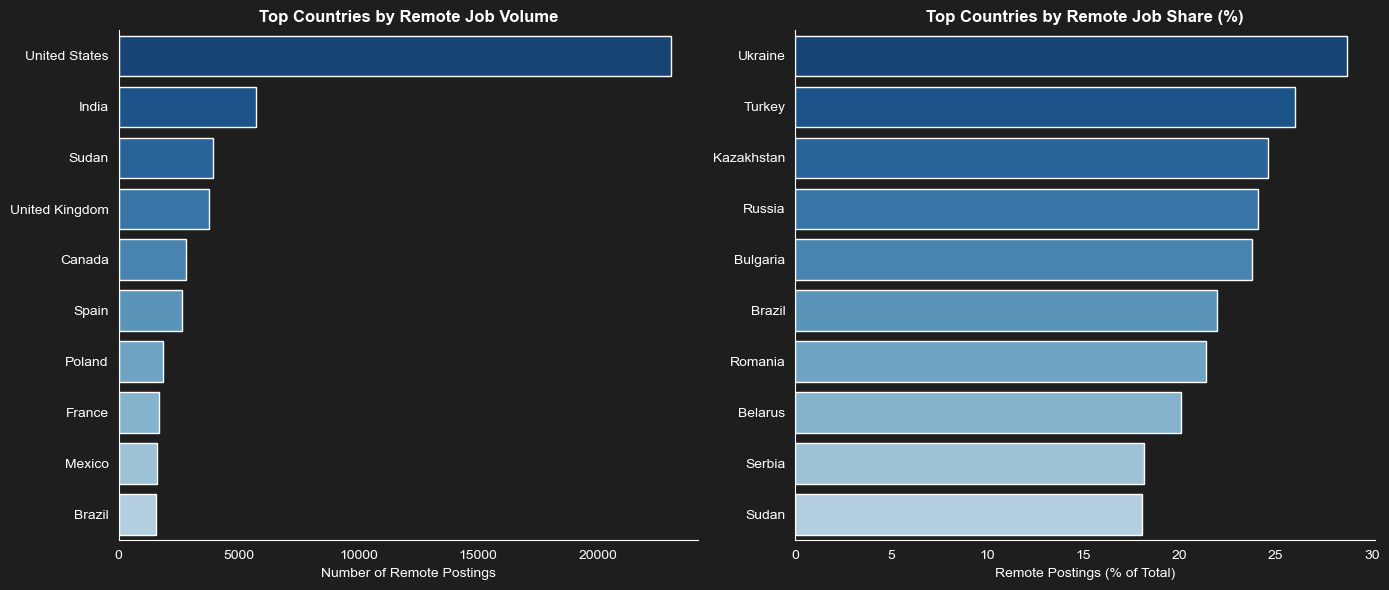

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bg_color = '#1e1e1e'  # dark charcoal
fig.patch.set_facecolor(bg_color)

def get_dark_bg_palette(n):
    # Generate extra shades from 'Blues' and drop the lightest ones,
    # so every bar stays visible against a dark background
    full_palette = sns.color_palette('Blues', n_colors=n + 4)
    return full_palette[4:][::-1]  # drop lightest 4, then reverse (darkest value = brightest bar)

# Left plot: raw remote counts
top_volume = top_remote_countries.reset_index()
top_volume.columns = ['job_country', 'remote_count']
palette_volume = get_dark_bg_palette(len(top_volume))
sns.barplot(data=top_volume, y='job_country', x='remote_count', hue='job_country', 
            palette=palette_volume, legend=False, ax=axes[0])
axes[0].set_facecolor(bg_color)
axes[0].set_title('Top Countries by Remote Job Volume', fontsize=12, weight='bold', color='white')
axes[0].set_xlabel('Number of Remote Postings', color='white')
axes[0].set_ylabel('')
axes[0].tick_params(colors='white')
axes[0].grid(False)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['left', 'bottom']].set_color('white')

# Right plot: remote share %
top_share = top_remote_share.reset_index()
palette_share = get_dark_bg_palette(len(top_share))
sns.barplot(data=top_share, y='job_country', x='remote_pct', hue='job_country',
            palette=palette_share, legend=False, ax=axes[1])
axes[1].set_facecolor(bg_color)
axes[1].set_title('Top Countries by Remote Job Share (%)', fontsize=12, weight='bold', color='white')
axes[1].set_xlabel('Remote Postings (% of Total)', color='white')
axes[1].set_ylabel('')
axes[1].tick_params(colors='white')
axes[1].grid(False)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['left', 'bottom']].set_color('white')

plt.tight_layout()
plt.savefig('../images/remote_volume_vs_share.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

### Top Job Titles Offering Remote Work

In [18]:
top_remote_roles = (
    df[df['job_work_from_home'] == True]['job_title_short']
    .value_counts()
    .head(10)
)
top_remote_roles

job_title_short
Data Engineer                21211
Data Scientist               14535
Data Analyst                 13326
Senior Data Engineer          6559
Senior Data Scientist         3799
Software Engineer             2930
Business Analyst              2789
Senior Data Analyst           2344
Machine Learning Engineer     1488
Cloud Engineer                 571
Name: count, dtype: int64

### Remote Share Within Each Job Title
As with countries, raw remote counts by role mostly reflect overall posting volume. Checking the *share* of remote postings within each role gives a clearer picture of where remote work is most common relative to total demand.

In [19]:
role_remote_share = (
    df.groupby('job_title_short')['job_work_from_home']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'remote_count', 'count': 'total_postings'})
)
role_remote_share['remote_pct'] = (role_remote_share['remote_count'] / role_remote_share['total_postings']) * 100

top_role_share = role_remote_share.sort_values('remote_pct', ascending=False)
top_role_share

,remote_count,total_postings,remote_pct
job_title_short,,,
Senior Data Engineer,6559,44563,14.718488
Data Engineer,21211,186241,11.389007
Machine Learning Engineer,1488,14080,10.568182
Senior Data Scientist,3799,36957,10.279514
Data Scientist,14535,172286,8.436553
Senior Data Analyst,2344,29216,8.023001
Data Analyst,13326,196075,6.796379
Software Engineer,2930,44929,6.521400
Business Analyst,2789,49063,5.684528


**Finding**: Unlike the country-level analysis, volume and remote share tell a consistent story here. Data Engineer roles show a notably higher remote share (11.4%) than Data Analyst roles (6.8%); nearly double. Senior-level positions are also consistently more remote-friendly than their non-senior counterparts across all roles. For a hybrid Data Analyst/Data Engineer path, this suggests that growing toward data engineering skills meaningfully improves remote job prospects.

### Visualizing Remote Share by Role

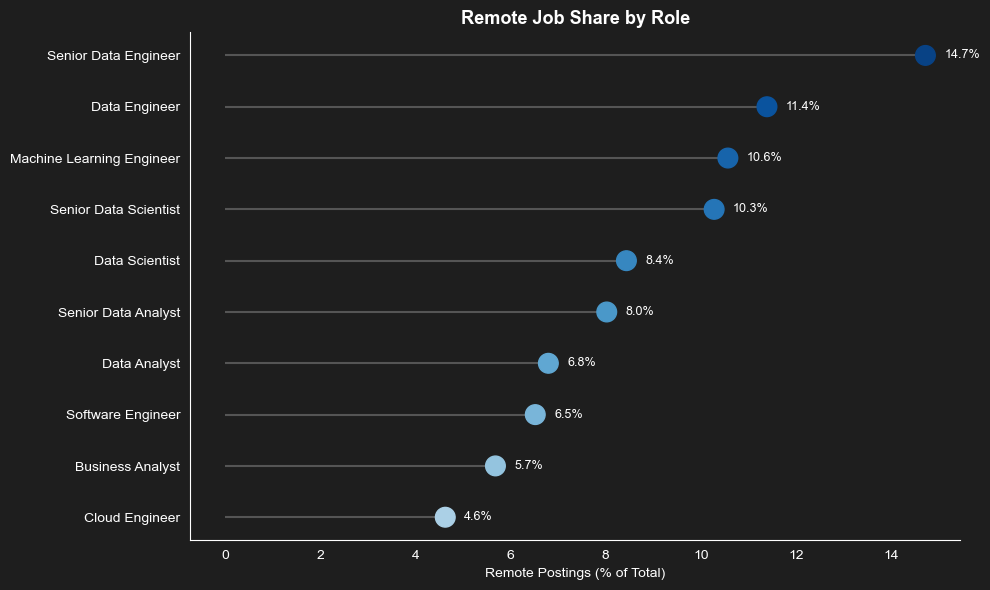

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
bg_color = '#1e1e1e'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

data = top_role_share.reset_index().sort_values('remote_pct', ascending=True)

# Gradient colors: highest value = brightest blue
colors = sns.color_palette('Blues', n_colors=len(data) + 4)[4:]

# Lines (stems)
ax.hlines(y=data['job_title_short'], xmin=0, xmax=data['remote_pct'], color='#555555', linewidth=1.5)

# Dots (lollipop heads)
ax.scatter(data['remote_pct'], data['job_title_short'], color=colors, s=200, zorder=3)

# Value labels next to each dot
for i, (val, role) in enumerate(zip(data['remote_pct'], data['job_title_short'])):
    ax.text(val + 0.4, i, f'{val:.1f}%', va='center', color='white', fontsize=9)

ax.set_title('Remote Job Share by Role', fontsize=13, weight='bold', color='white')
ax.set_xlabel('Remote Postings (% of Total)', color='white')
ax.set_ylabel('')
ax.tick_params(colors='white')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('white')

plt.tight_layout()
plt.savefig('../images/remote_share_by_role.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

## Summary

- Remote postings represent **8.85%** of all job listings in this dataset.
- Volume and remote *share* tell different stories at the country level: the US, India, and the UK have the most remote postings in absolute terms, but the highest remote **share** relative to total postings is found in Ukraine (28.7%), Turkey (26.0%), and Kazakhstan (24.6%) — countries with smaller overall volume but a stronger relative pull toward remote work.
- At the role level, volume and share align consistently: **Data Engineer** roles have a remote share of 11.4%, nearly double that of **Data Analyst** roles (6.8%). Senior-level positions are also consistently more remote-friendly than their non-senior counterparts across every role.
- **Takeaway**: growing toward data engineering skills — and seniority over time — appears to meaningfully improve the odds of finding remote work, more so than targeting any single country by job volume alone.